In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rubin_scheduler.site_models import SeeingModel

import rubin_nights.plot_utils as rn_plots
band_colors = rn_plots.PlotStyles().band_colors

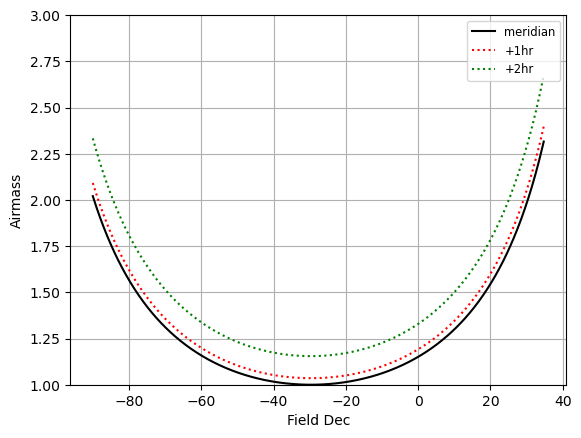

In [53]:
# AIRMASS

tele_lat = -29.666667

dec_min = np.max([tele_lat-90, -90])
dec_max = np.min([tele_lat+90, 35])
field_dec = np.arange(dec_min, dec_max, 0.25)

min_z = np.radians(np.abs(field_dec - tele_lat))
min_airmass = 1 / np.cos(min_z)

# Add expected airmass for +/- 1 & 2 hours around meridian
# cos z  =cos(min_z) * cos(ha_offset)
ha_offset = np.radians(15)
plus_1hr = np.arccos(np.cos(min_z) * np.cos(ha_offset))
ha_offset = np.radians(30)
plus_2hr = np.arccos(np.cos(min_z) * np.cos(ha_offset))

airmass_1hr = 1. / np.cos(plus_1hr)
airmass_2hr = 1. / np.cos(plus_2hr)

plt.plot(field_dec, min_airmass, 'k-', label='meridian')
plt.plot(field_dec, airmass_1hr, 'r:', label='+1hr')
plt.plot(field_dec, airmass_2hr, 'g:', label='+2hr')
plt.legend(loc='upper right', fancybox=True, fontsize='small')
plt.xlabel('Field Dec')
plt.ylabel('Airmass')
plt.ylim(1, 3)
plt.grid(True)

In [67]:
# from rubin_nights import connections
# from rubin_nights.reference_values import SCIENCE_PROGRAMS

# programs = tuple([p for p in SCIENCE_PROGRAMS if p!='BLOCK_365' and p!='BLOCK-408'])
# endpoints = connections.get_clients()
# query = f"select dimm_seeing, airmass, band, psf_sigma_median, seeing_zenith_500nm_median, "\
#         f"donut_blur_fwhm, aos_fwhm, ringss_seeing from cdb_lsstcam.visit1 left join cdb_lsstcam.visit1_quicklook "\
#         f"on visit1.visit_id = visit1_quicklook.visit_id where science_program in {programs} and img_type = 'science'"
# dimm = endpoints['consdb'].query(query)

# cols = ['dimm_seeing', 'donut_blur_fwhm',]
# _ = plt.hist(dimm[cols], bins=np.arange(0, 3.0, 0.1), label=cols)
# _ = plt.legend()
# dimm.describe()

Text(0, 0.5, 'DIQ FWHM (arcsec) with 0.7 atmosphere')

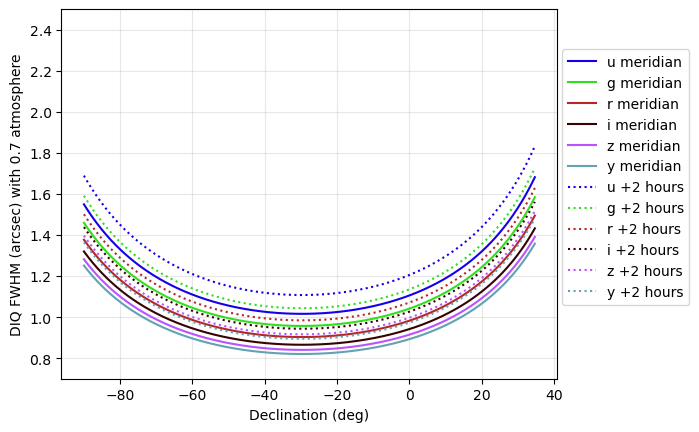

In [37]:
# seeing changes with declination

seeing = SeeingModel()

atm = 0.7
diq = seeing(atm, min_airmass)['fwhmEff']
for i, band in enumerate("ugrizy"):
    plt.plot(field_dec, diq[i,:], color=band_colors[band], label=f"{band} meridian")
diq = seeing(atm, airmass_2hr)['fwhmEff']
for i, band in enumerate("ugrizy"):
    plt.plot(field_dec, diq[i,:], color=band_colors[band], linestyle=':', label=f"{band} +2 hours")
plt.legend(loc=(1.01, 0.2))
#plt.axhline(1.4)
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 2.5)
plt.xlabel("Declination (deg)")
plt.ylabel(f"DIQ FWHM (arcsec) with {atm} atmosphere")

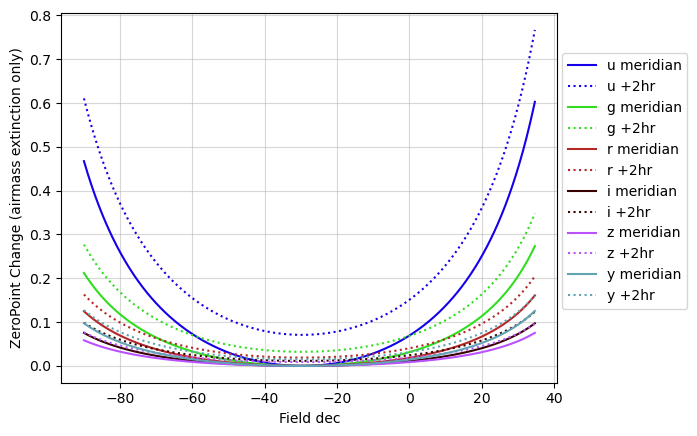

In [48]:
# zeropoint changes with declination
extinction_coeff = {
        "u": -0.45815823969467745,
        "g": -0.20789273881603035,
        "r": -0.12233514157672552,
        "i": -0.07387773563152214,
        "z": -0.0573260392897174,
        "y": -0.09549137502152871,
    }

plt.figure()

zero_point_diff = {}
zero_point_diff_2 = {}
for b in 'ugrizy':
    zero_point_diff[b] = (1 - min_airmass) * extinction_coeff[b]
    plt.plot(field_dec, zero_point_diff[b], color=band_colors[b], label=f"{b} meridian")
    zero_point_diff_2[b] = (1 - airmass_2hr) * extinction_coeff[b]
    plt.plot(field_dec, zero_point_diff_2[b], color=band_colors[b], linestyle=':', label=f"{b} +2hr")
plt.legend(loc=(1.01, 0.2))
plt.xlabel("Field dec")
plt.ylabel("ZeroPoint Change (airmass extinction only)")
plt.grid(alpha=0.5)

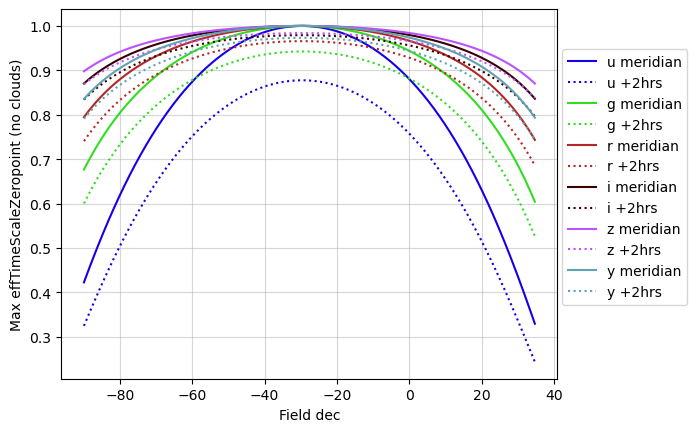

In [52]:
# zeropoint changes with declination (in effective time)

plt.figure()
for b in 'ugrizy':
    max_eff_time = 10**(-0.8 * zero_point_diff[b])
    plt.plot(field_dec, max_eff_time, color=band_colors[b], label=f"{b} meridian")
    max_eff_time = 10**(-0.8 * zero_point_diff_2[b])
    plt.plot(field_dec, max_eff_time, color=band_colors[b], linestyle=':', label=f"{b} +2hrs")
plt.legend(loc=(1.01, 0.2))
plt.xlabel("Field dec")
plt.ylabel("Max effTimeScaleZeropoint (no clouds)")
plt.grid(alpha=0.5)